# 🚴 Food Delivery Analysis - Classification Track
**Capstone Project - Review 1 (Part A) & Review 2 (Part B) Deliverable**  
**Target Variable**: `is_late` (Binary: `1` if `Time_taken(min) > 30` mins, else `0`)  
**Objective**: Build and compare 10 Classification models to predict late delivery risk.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

# Load raw dataset
df = pd.read_csv('../data/food_delivery.csv')

# Clean string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False)
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')
df = df.dropna(subset=['Time_taken(min)'])

# Create Binary Classification Target: is_late (1 if > 30 mins, else 0)
df['is_late'] = (df['Time_taken(min)'] > 30).astype(int)

# Clean numeric features safely
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Calculate distance_km
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6367 * c

df['distance_km'] = haversine_np(
    df['Restaurant_longitude'], df['Restaurant_latitude'],
    df['Delivery_location_longitude'], df['Delivery_location_latitude']
)
df['distance_km'] = df['distance_km'].apply(lambda x: df['distance_km'].median() if x > 100 or x <= 0 or pd.isna(x) else x)

# Impute categorical columns
cat_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
for col in cat_cols:
    df[col] = df[col].str.replace('conditions ', '', regex=False).fillna(df[col].mode()[0])


display(df.head())
print("Class Distribution:\n", df['is_late'].value_counts(normalize=True))


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),is_late,distance_km
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,High,2,Snack,motorcycle,0.0,No,Urban,24,0,3.023250
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,1,20.170858
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Low,0,Drinks,motorcycle,1.0,No,Urban,26,0,1.551783
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,0,7.785510
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,High,1,Snack,scooter,1.0,No,Metropolitian,30,0,6.206239


Class Distribution:
 is_late
0    0.701577
1    0.298423
Name: proportion, dtype: float64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 'multiple_deliveries',
            'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']

X = pd.get_dummies(df[features], drop_first=True)
y = df['is_late']

# Stratified Train/Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")



Train Shape: (36474, 25), Test Shape: (9119, 25)


---
## 🎯 Section D: Classification Track - Part A (Evaluated in Review 1)
Evaluating the first 5 classifiers:
1. Logistic Regression
2. K-Nearest Neighbors Classifier
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVC)



In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

part_a_results = []

def eval_classifier(name, model, X_tr, X_te, y_tr=None, y_te=None):
    if y_tr is None:
        y_tr = y_train
    if y_te is None:
        y_te = y_test
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else preds
    
    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='weighted')
    rec = recall_score(y_te, preds, average='weighted')
    f1 = f1_score(y_te, preds, average='weighted')
    auc = roc_auc_score(y_te, probs)
    
    part_a_results.append({
        'Algorithm': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    return model

# 1. Logistic Regression
log_reg = eval_classifier('Logistic Regression', LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled)

# 2. K-Nearest Neighbors
knn_clf = eval_classifier('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=7), X_train_scaled, X_test_scaled)

# 3. Naive Bayes
nb_clf = eval_classifier('Naive Bayes (Gaussian)', GaussianNB(), X_train_scaled, X_test_scaled)

# 4. Decision Tree
dt_clf = eval_classifier('Decision Tree Classifier', DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test)

# 5. Support Vector Machine (SVC)
svc_clf = eval_classifier('Support Vector Machine (SVC)', SVC(probability=True, kernel='rbf', C=1.0), X_train_scaled[:5000], X_test_scaled[:1000], y_tr=y_train[:5000], y_te=y_test[:1000])

print("--- Part A Preliminary Results ---")
display(pd.DataFrame(part_a_results))



--- Part A Preliminary Results ---


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.867749,0.865251,0.867749,0.864856,0.928778
1,K-Nearest Neighbors,0.879811,0.879196,0.879811,0.875662,0.930165
2,Naive Bayes (Gaussian),0.715978,0.725157,0.715978,0.621883,0.902767
3,Decision Tree Classifier,0.890558,0.900653,0.890558,0.883332,0.924654
4,Support Vector Machine (SVC),0.913000,0.916914,0.913000,0.909588,0.956930


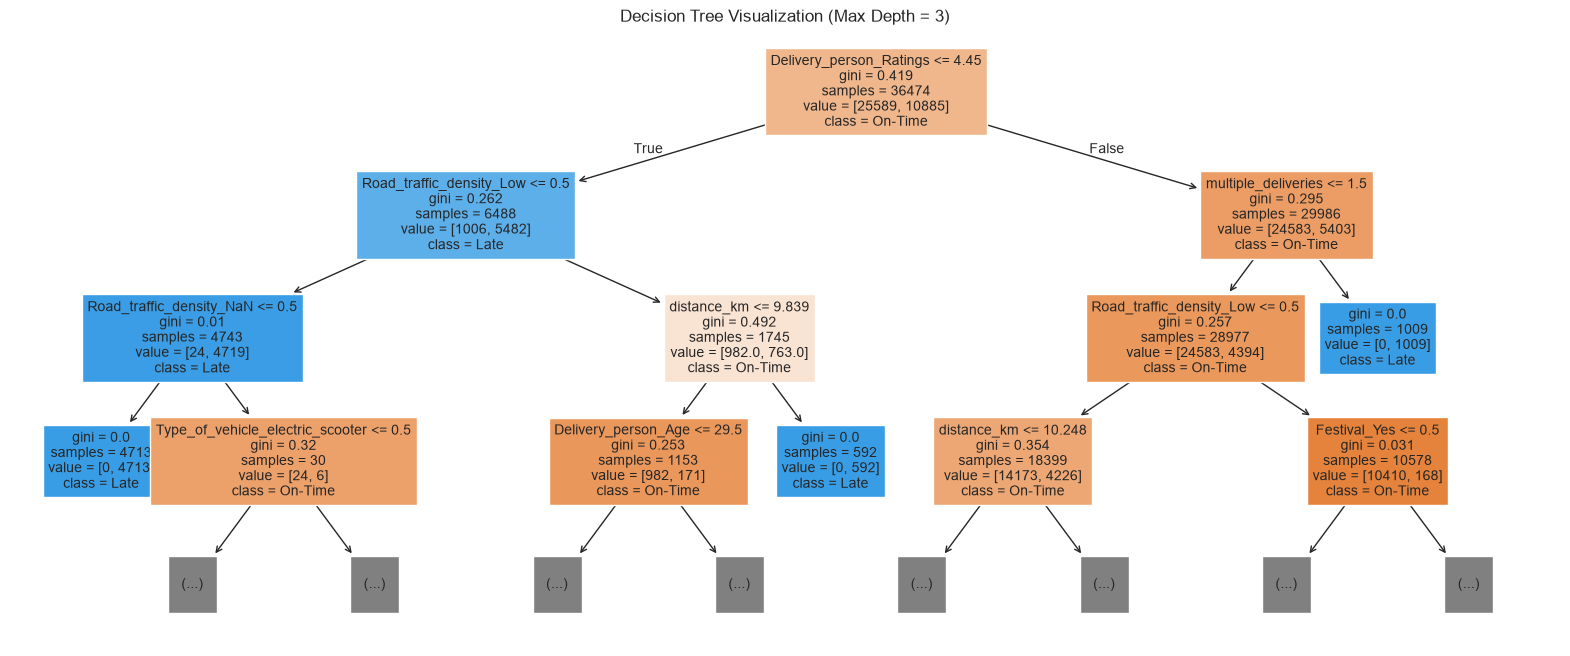

In [4]:
# Decision Tree Visualization (Review 1 Requirement)
plt.figure(figsize=(20, 8))
plot_tree(dt_clf, feature_names=X.columns, class_names=['On-Time', 'Late'], filled=True, max_depth=3, fontsize=10)
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()



---
## 🚀 Classification Track - Part B (Evaluated in Review 2)
Evaluating remaining 5 ensemble and neural network classifiers:
6. Random Forest Classifier
7. AdaBoost Classifier
8. Gradient Boosting Classifier (XGBoost)
9. Bagging Classifier
10. MLP Classifier (Neural Network)



In [5]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.neural_network import MLPClassifier

part_b_results = list(part_a_results) # combine with Part A

def eval_b(name, model, X_tr, X_te, y_tr=None, y_te=None):
    if y_tr is None:
        y_tr = y_train
    if y_te is None:
        y_te = y_test
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else preds
    
    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='weighted')
    rec = recall_score(y_te, preds, average='weighted')
    f1 = f1_score(y_te, preds, average='weighted')
    auc = roc_auc_score(y_te, probs)
    
    part_b_results.append({
        'Algorithm': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    return model

# 6. Random Forest
rf_clf = eval_b('Random Forest Classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), X_train, X_test)

# 7. AdaBoost
ada_clf = eval_b('AdaBoost Classifier', AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42), X_train, X_test)

# 8. Gradient Boosting
gb_clf = eval_b('Gradient Boosting Classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42), X_train, X_test)

# 9. Bagging Classifier
bag_clf = eval_b('Bagging Classifier', BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), n_estimators=50, random_state=42), X_train, X_test)

# 10. MLP Classifier (Neural Network)
mlp_clf = eval_b('MLP Classifier (Neural Net)', MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, random_state=42), X_train_scaled, X_test_scaled)

# Consolidated 10-Algorithm Comparison Table
full_results_df = pd.DataFrame(part_b_results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print("=== CONSOLIDATED 10-ALGORITHM CLASSIFICATION COMPARISON TABLE ===")
display(full_results_df)



=== CONSOLIDATED 10-ALGORITHM CLASSIFICATION COMPARISON TABLE ===


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting Classifier,0.919509,0.920427,0.919509,0.917353,0.974276
1,Support Vector Machine (SVC),0.913000,0.916914,0.913000,0.909588,0.956930
2,MLP Classifier (Neural Net),0.905801,0.904995,0.905801,0.905258,0.966378
3,Random Forest Classifier,0.905582,0.911600,0.905582,0.900890,0.967331
4,Decision Tree Classifier,0.890558,0.900653,0.890558,0.883332,0.924654
5,Bagging Classifier,0.890449,0.900564,0.890449,0.883205,0.926915
6,K-Nearest Neighbors,0.879811,0.879196,0.879811,0.875662,0.930165
7,Logistic Regression,0.867749,0.865251,0.867749,0.864856,0.928778
8,AdaBoost Classifier,0.866323,0.886778,0.866323,0.853067,0.920615
9,Naive Bayes (Gaussian),0.715978,0.725157,0.715978,0.621883,0.902767
